# Análisis exploratorio de incidencia delictiva en México

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv('data/delitos.csv',encoding='latin1')

In [4]:
# 1. Cargamos el archivo
df = pd.read_csv('data/delitos.csv', encoding='latin1')

# 2. Limpieza radical de encabezados
# Quitamos espacios, pasamos a minúsculas y eliminamos caracteres especiales invisibles
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

# 3. IDENTIFICADOR DE COLUMNAS (Para que no falle por nombres)
# Buscamos la columna que se parezca a 'frecuencia' y a 'fecha'
col_frecuencia = [c for c in df.columns if 'frecu' in c][0]
col_fecha = [c for c in df.columns if 'fech' in c][0]
col_delito = [c for c in df.columns if 'delito' in c][0]
col_entidad = [c for c in df.columns if 'entidad' in c or 'estado' in c][0]
col_anio = [c for c in df.columns if 'anio' in c or 'año' in c][0]

# 4. Convertimos tipos de datos usando nuestros "detectores"
df[col_fecha] = pd.to_datetime(df[col_fecha])
df[col_frecuencia] = pd.to_numeric(df[col_frecuencia], errors='coerce').fillna(0)


display(df.head())

,anio,clave_ent,entidad,tipo_de_delito,nombre_mes,fecha,frecuencia
0,2015,1,Aguascalientes,Aborto,abril,2015-04-01,0.0
1,2015,1,Aguascalientes,Aborto,agosto,2015-08-01,0.0
2,2015,1,Aguascalientes,Aborto,diciembre,2015-12-01,0.0
3,2015,1,Aguascalientes,Aborto,enero,2015-01-01,0.0
4,2015,1,Aguascalientes,Aborto,febrero,2015-02-01,3.0


#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

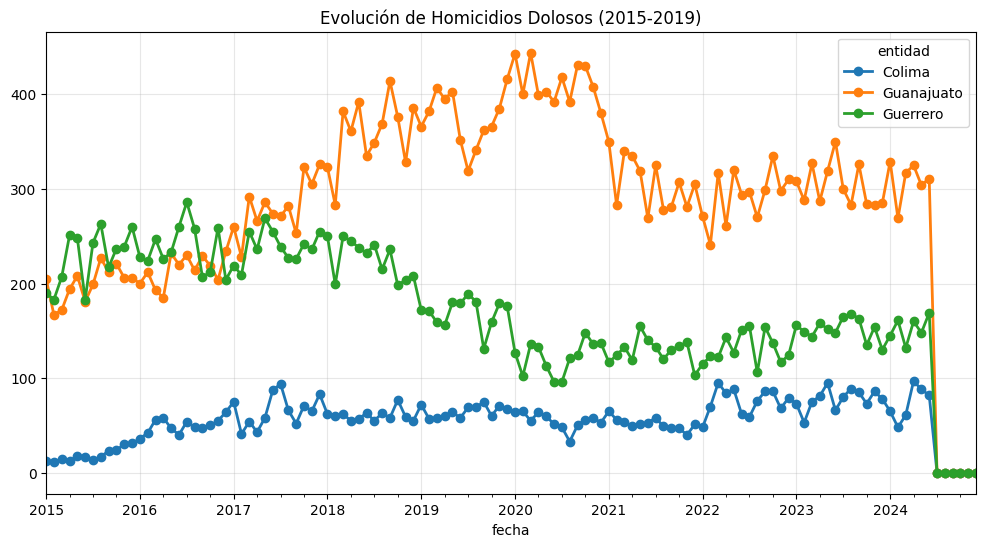

In [5]:
# Elegimos 3 estados (Ojo: los nombres en del archivo tienen mayúsculas)
estados_top = ['Colima', 'Guerrero', 'Guanajuato']

# Filtramos usando los nombres que detectamos arriba
df_homicidios = df[(df[col_delito].str.contains('Homicidio', case=False)) & 
                   (df[col_entidad].isin(estados_top))]

# Agrupamos y graficamos
serie_t = df_homicidios.groupby([col_fecha, col_entidad])[col_frecuencia].sum().unstack()

serie_t.plot(figsize=(12,6), marker='o', linewidth=2)
plt.title('Evolución de Homicidios Dolosos (2015-2019)')
plt.grid(True, alpha=0.3)
plt.show()



#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [10]:
# --- 0. Identificamos columnas de forma segura ---
# Buscamos municipio, si no existe, usamos la entidad para que el código siga
cols_muni = [c for c in df.columns if 'muni' in c.lower()]
col_municipio = cols_muni[0] if cols_muni else col_entidad

# Buscamos la columna de Mes (por si acaso no se llama exactamente 'mes')
cols_mes = [c for c in df.columns if 'mes' in c.lower()]
col_mes = cols_mes[0] if cols_mes else col_fecha

# --- PREGUNTA 1: Homicidios dolosos en Colima (2018) ---
q1 = df[(df[col_delito].str.contains('Homicidio doloso', case=False, na=False)) & 
        (df[col_entidad].str.contains('Colima', case=False, na=False)) & 
        (df[col_anio] == 2018)]
print(f"1. Total homicidios dolosos en Colima (2018): {q1[col_frecuencia].sum()}")

# --- PREGUNTA 2: Robos de vehículo (2019) ---
q2 = df[(df[col_delito].str.contains('Robo de vehículo', case=False, na=False)) & 
        (df[col_anio] == 2019)]
print(f"2. Total robos de vehículo en 2019: {q2[col_frecuencia].sum()}")

# --- PREGUNTA 3: Homicidios + Feminicidios por año ---
q3 = df[df[col_delito].str.contains('Homicidio doloso|Feminicidio', case=False, na=False)]
resumen_q3 = q3.groupby(col_anio)[col_frecuencia].sum()
print("\n3. Suma anual (Homicidios dolosos + Feminicidios):")
print(resumen_q3)

# --- PREGUNTA 4: Max Feminicidios (Mes y Municipio/Estado) ---
q4_base = df[df[col_delito].str.contains('Feminicidio', case=False, na=False)]
if not q4_base.empty:
    idx_max = q4_base[col_frecuencia].idxmax()
    reg = q4_base.loc[idx_max]
    lugar = reg[col_municipio]
    print(f"\n4. El mayor número de feminicidios ocurrió en el mes de {reg[col_mes]} "
          f"en {lugar} con {reg[col_frecuencia]} casos.")

# --- PREGUNTA 5: Max Feminicidios (Año y Estado) ---
q5_agrupado = q4_base.groupby([col_anio, col_entidad])[col_frecuencia].sum().reset_index()
if not q5_agrupado.empty:
    idx_max_5 = q5_agrupado[col_frecuencia].idxmax()
    reg5 = q5_agrupado.loc[idx_max_5]
    print(f"5. El año y estado con más feminicidios fue {reg5[col_entidad]} "
          f"en el {int(reg5[col_anio])} con {reg5[col_frecuencia]} casos.")

1. Total homicidios dolosos en Colima (2018): 0.0
2. Total robos de vehículo en 2019: 0.0

3. Suma anual (Homicidios dolosos + Feminicidios):
anio
2015    413.0
2016    608.0
2017    744.0
2018    899.0
2019    944.0
2020    947.0
2021    981.0
2022    961.0
2023    832.0
2024    401.0
Name: frecuencia, dtype: float64

4. El mayor número de feminicidios ocurrió en el mes de julio en MÃ©xico con 19.0 casos.
5. El año y estado con más feminicidios fue MÃ©xico en el 2020 con 151.0 casos.


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

/tmp/ipykernel_789/1573827469.py:11: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


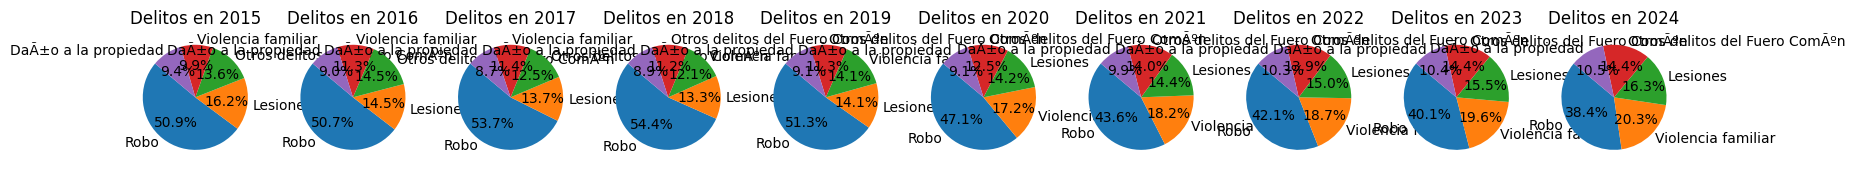

In [8]:
anios_lista = sorted(df[col_anio].unique())
fig, axes = plt.subplots(1, len(anios_lista), figsize=(20, 5))

for i, a in enumerate(anios_lista):
    resumen = df[df[col_anio] == a].groupby(col_delito)[col_frecuencia].sum()
    # Graficamos el Top 5 para que se entienda la gráfica
    resumen.sort_values(ascending=False).head(5).plot(kind='pie', ax=axes[i], autopct='%1.1f%%', startangle=140)
    axes[i].set_title(f'Delitos en {a}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [7]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0
